# Hamiltonian Simulation: Real-Time Dynamics

This notebook solves a small real-time Schrodinger dynamics problem by applying the matrix function `exp(-iHt)` to an initial state. QSVT can express real and imaginary parts of this unitary evolution through bounded polynomial transforms of a rescaled Hamiltonian.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a small tight-binding Schrödinger dynamics problem.

**QSVT implementation.** It approximates real and imaginary components of time evolution with polynomial transforms. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral time evolution validates site probabilities and phase response. Hamiltonian simulation is a central quantum use case for block-encoded operators; this notebook keeps the instance tiny to make the transform transparent.


## Variable definitions

- `n_sites`: number of sites in the tight-binding chain.
- `time`: physical evolution time.
- `H`: tight-binding Hamiltonian.
- `evals`: eigenvalues of `H`.
- `scale`: spectral radius used for rescaling.
- `A`: Hamiltonian rescaled to the polynomial interval.
- `tau`: dimensionless time `scale * time`.
- `psi0`: initial quantum state.
- `evolution`: cosine and sine polynomial design result.
- `U_poly_psi`: state evolved by the polynomial approximation.
- `U_exact_psi`: state evolved by exact spectral time evolution.
- `state_error`: norm error between polynomial and exact evolved states.
- `xs`, `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)
from qsvt.hamiltonians import tight_binding_chain
from qsvt.matrix_functions import design_real_time_evolution_polynomials

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_sites = 6
time = 1.4
H = tight_binding_chain(n_sites)
evals, _ = eigh_hermitian(H)
scale = np.max(np.abs(evals))
A = H / scale
tau = scale * time

psi0 = np.zeros(n_sites, dtype=complex)
psi0[1] = 1.0

evolution = design_real_time_evolution_polynomials(time=time, scale=scale, degree=19)

U_poly_psi = (
    apply_polynomial_to_hermitian(A, evolution.cos_coeffs)
    - 1j * apply_polynomial_to_hermitian(A, evolution.sin_coeffs)
) @ psi0
U_exact_psi = (
    apply_function_to_hermitian(H, lambda lam: np.exp(-1j * time * lam)) @ psi0
)

state_error = np.linalg.norm(U_poly_psi - U_exact_psi)
print(f"State Error: {state_error}")

State Error: 3.324978121461713e-13


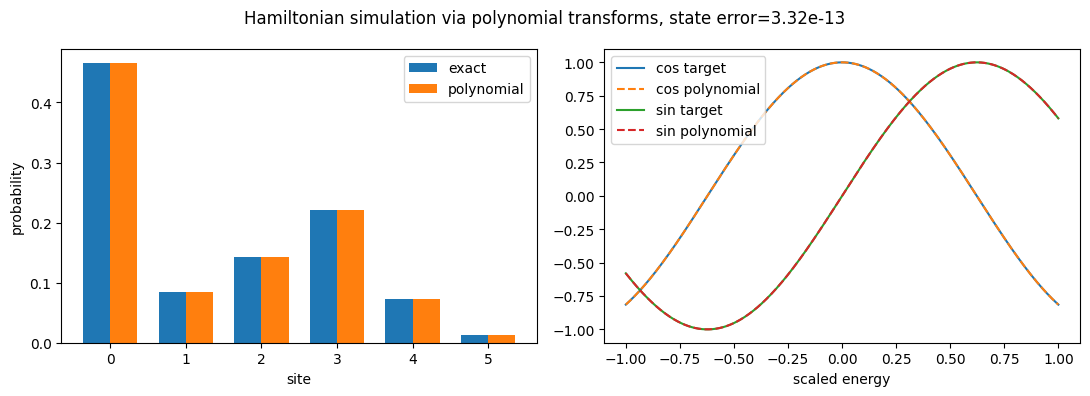

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(n_sites) - 0.18, np.abs(U_exact_psi) ** 2, 0.36, label="exact")
axes[0].bar(
    np.arange(n_sites) + 0.18, np.abs(U_poly_psi) ** 2, 0.36, label="polynomial"
)
axes[0].set_xlabel("site")
axes[0].set_ylabel("probability")
axes[0].legend()

xs = np.linspace(-1, 1, 500)
axes[1].plot(xs, np.cos(tau * xs), label="cos target")
axes[1].plot(
    xs, eval_polynomial(evolution.cos_coeffs, xs), "--", label="cos polynomial"
)
axes[1].plot(xs, np.sin(tau * xs), label="sin target")
axes[1].plot(
    xs, eval_polynomial(evolution.sin_coeffs, xs), "--", label="sin polynomial"
)
axes[1].set_xlabel("scaled energy")
axes[1].legend()
fig.suptitle(
    f"Hamiltonian simulation via polynomial transforms, state error={state_error:.2e}"
)
plt.tight_layout()
plt.show()